# 01 - Exploring the AG News Dataset  

This notebook explores the AG News dataset before any preprocessing or model training:

Goals:
* Understand the dataset structure.
* Inspect labels and examples.
* Explore class balances.
* prepare the data for transformer tokenisation.

In [1]:
# import dataset
from news_sense.dataset import load_news_dataset
from news_sense.plotting import (
    set_plot_style,
    get_colour,
    get_palette
)
set_plot_style()

# import libraries
from datasets import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Section 1 - Load the dataset

In [2]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)



datasets: 5.0.1
huggingface_hub: 1.31.0


In [3]:
dataset = load_news_dataset()

dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [4]:
train = dataset["train"]
test = dataset["test"]

In [5]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

## Section 2 - Explore one split

In [6]:
train_df.head(10)

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


In [7]:
test_df.head(10)

,label,title,description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
5,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...
6,4,Loosing the War on Terrorism,"\\""Sven Jaschan, self-confessed author of the ..."
7,4,"FOAFKey: FOAF, PGP, Key Distribution, and Bloo...",\\FOAF/LOAF and bloom filters have a lot of i...
8,4,E-mail scam targets police chief,"Wiltshire Police warns about ""phishing"" after ..."
9,4,"Card fraud unit nets 36,000 cards","In its first two years, the UK's dedicated car..."


In [8]:
# I want to look at how long the titles and descriptions are in the dataset. I will create a new column in the dataframe that contains the length of the title and description.

train_df["title_length"] = train_df["title"].str.len()
train_df["description_length"] = train_df["description"].str.len()


print(f"title length summary: {train_df['title_length'].describe()}\n\n")
print(f"description length summary: {train_df['description_length'].describe()}")

title length summary: count    120000.000000
mean         42.075508
std          13.563871
min           6.000000
25%          33.000000
50%          41.000000
75%          49.000000
max         115.000000
Name: title_length, dtype: float64


description length summary: count    120000.000000
mean        193.402017
std          64.452006
min          20.000000
25%         155.000000
50%         188.000000
75%         219.000000
max         985.000000
Name: description_length, dtype: float64


In [9]:
print(f"train_df label datatypes: {train_df.dtypes}\n\n")

train_df label datatypes: label                  int64
title                 object
description           object
title_length           int64
description_length     int64
dtype: object




each record has 3 fields:
* `label` - contains an integer (1 - 4 inc.) representing the topic code of the article, 1: World 2: Sports 3: Business 4: Sci/Tech
* `title` - contains the original title of the article*
* `description` - contains a description of the article's content*

*"The title and description are escaped using double quotes ("), and any internal double quote is escaped by 2 double quotes (""). New lines are escaped by a backslash followed with an "n" character, that is "\n"." - https://huggingface.co/datasets/sh0416/ag_news

### Class balance

Label counts:
label
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


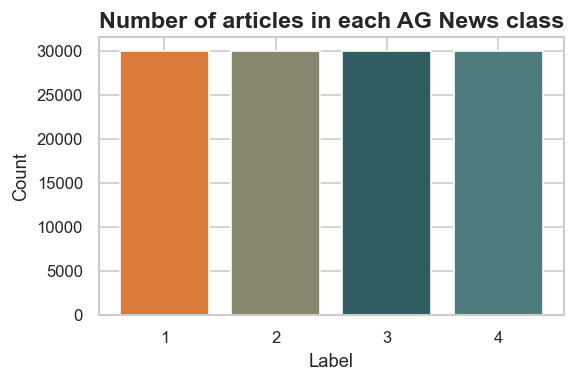

<Figure size 960x600 with 0 Axes>

In [18]:
label_counts = train_df["label"].value_counts()
print(f"Label counts:\n{label_counts}")

# plot using the viridis color palette and set the figure size to 5x3 inches
plt.subplots(figsize=(5, 3))
plt.bar(label_counts.index, (label_counts.values), color=get_palette(4))
plt.title("Number of articles in each AG News class")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(label_counts.index, rotation=0)

plt.show()

plt.savefig("../figures/class_distribution.png", dpi=300)

### Article Lengths

In [20]:
article_lengths = [len(article.split()) for article in train_df["description"]]
length_series = pd.Series(article_lengths)

length_series.describe()

count    120000.000000
mean         31.062692
std           9.757035
min           3.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
dtype: float64

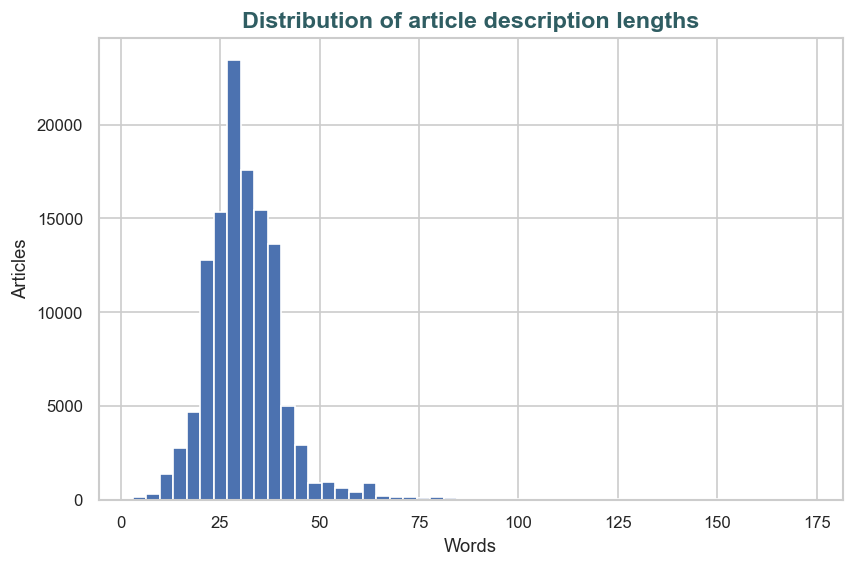

<Figure size 960x600 with 0 Axes>

In [27]:
plt.hist(article_lengths, bins=50)

plt.title("Distribution of article description lengths", color=get_colour("primary"))
plt.xlabel("Words")
plt.ylabel("Articles")

plt.show()

plt.savefig("../figures/description_lengths.png", dpi=300)

### Article Explorer

In [40]:
rng = np.random.default_rng(36)

random_index = rng.integers(len(train))
print(random_index)

example = train_df.loc[random_index]

print(example["label"])
print()
print(example["description"])

45983
1

British Prime Minister Tony Blair said he would undergo a routine operation Friday to correct an irregular heartbeat. Blair announced the plans for the medical procedure Thursday night, just hours after 
